In [ ]:
!pip install faker pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 18.1 MB/s eta 0:00:00


In [ ]:
from faker import Faker
import pandas as pd
import random
import datetime
fake = Faker()

In [ ]:


# Step 2: Initialize Faker
fake = Faker()

# Step 3: Generate Users Data
users = []

for i in range(100000):  # 50k users
    # Subscription dates
    start_date = fake.date_between(start_date='-5y', end_date='today')
    end_date = start_date + datetime.timedelta(days=random.randint(30, 365))

    # Email: sometimes missing
    email = fake.unique.email()  # guarantees no duplicates
    # Name: messy capitalization
    name = fake.name()
    if random.random() > 0.5:
        name = name.upper()

    # Age: 18–75
    age = random.randint(18, 75)

    # Gender
    gender = random.choice(['Male', 'Female', 'other'])

    # Country
    country = fake.country()

    # Subscription type
    subscription_type = random.choice(['Basic', 'Standard', 'Premium'])

    # Format dates for MySQL
    start_date = start_date.strftime('%Y-%m-%d')
    end_date = end_date.strftime('%Y-%m-%d')

    users.append([
        name,
        email,
        age,
        gender,
        country,
        subscription_type,
        start_date,
        end_date
    ])

# Step 4: Create DataFrame
users_df = pd.DataFrame(users, columns=[
    'name',
    'email',
    'age',
    'gender',
    'country',
    'subscription_type',
    'subscription_start',
    'subscription_end'
])

# Step 5: Save CSV for MySQL
# NULL emails will be saved as NULL (MySQL-compatible)
users_df.to_csv("users.csv", index=False, na_rep='NULL')

# Step 6: Check first 5 rows
users_df.head(10)

,name,email,age,gender,country,subscription_type,subscription_start,subscription_end
0,BECKY ARNOLD,gonzalezelizabeth@example.com,35,Female,Austria,Premium,2024-11-23,2025-02-25
1,JONATHAN RICHARDS,tsmith@example.org,53,Female,Sweden,Premium,2025-03-04,2025-05-21
2,DEBRA JONES,jessica16@example.org,67,Female,United Arab Emirates,Standard,2021-12-29,2022-04-12
3,Virginia Thornton,james50@example.net,48,Male,Maldives,Premium,2022-05-15,2022-11-10
4,Danny Miller,troy53@example.net,31,Female,Kiribati,Premium,2021-07-22,2022-05-18
5,MARK JOHNS,umiller@example.com,70,Female,Timor-Leste,Basic,2025-10-21,2026-06-13
6,Paul Hodge,juan54@example.com,37,Female,Macao,Premium,2025-05-21,2026-01-29
7,Patricia Scott,brandyguerra@example.net,31,Female,Senegal,Basic,2023-07-11,2024-05-14
8,Kimberly White,johnjones@example.com,65,other,Bulgaria,Standard,2024-08-27,2025-03-17
9,Savannah Hamilton,vazquezmakayla@example.org,68,Male,Sudan,Standard,2023-05-17,2024-05-12


In [ ]:
# Step: Generate View table data
fake = Faker()

genres = ['Action', 'Horror', 'Comedy', 'Drama', 'Sci-Fi', 'Documentary', 'Romance', 'Thriller']

content = []

for i in range(50000):
    title = fake.sentence(nb_words=3).replace('.', '')

    # realistic duration
    duration = round(random.uniform(20, 180), 2)

    # realistic rating (more centered around 3–4)
    rating = round(random.uniform(2.0, 4.8), 1)

    content.append([
        title,
        random.choice(genres),
        duration,
        random.randint(1980, 2025),
        rating
    ])

content_df = pd.DataFrame(content, columns=[
    'title',
    'genre',
    'duration_min',
    'release_year',
    'rating'
])

content_df.head()

,title,genre,duration_min,release_year,rating
0,Ahead wife,Romance,78.14,2022,4.8
1,Foreign mouth,Horror,90.01,1987,2.8
2,Administration site nation,Thriller,32.23,2014,2.8
3,Open end national,Action,110.49,2010,3.5
4,School really,Romance,65.05,1982,2.1


In [ ]:
# Step: Generate View table data

from faker import Faker
import pandas as pd
import random
import datetime

fake = Faker()

# ---- 1. Define valid IDs ----
# User IDs that actually exist in MySQL users table
valid_user_ids = list(range(172, 100172))  # MIN=172, MAX=100171

# Content IDs that actually exist in MySQL content table
valid_content_ids = list(range(1, 50001))  # assuming 50,000 content rows

# Device types
device_types = ['Mobile', 'Desktop', 'Smart_TV', 'Tablet']

# ---- 2. Generate messy View data ----
view_data = []
num_rows = 300000  # number of view records

for _ in range(num_rows):
    user_id = random.choice(valid_user_ids)           # only valid User_id
    content_id = random.choice(valid_content_ids)    # only valid Content_id
    watch_date = fake.date_time_between(start_date='-5y', end_date='now')
    watch_date_str = watch_date.strftime('%Y-%m-%d %H:%M:%S')  # MySQL datetime format
    watch_time = round(random.uniform(5, 180), 2)   # minutes watched
    device = random.choice(device_types)

    # Append as a row
    view_data.append([user_id, content_id, watch_date_str, watch_time, device])

# ---- 3. Create DataFrame ----
view_df = pd.DataFrame(view_data, columns=[
    'User_id', 'content_id', 'watch_date', 'watch_time_minutes', 'device_type'
])

# ---- 4. Preview ----
print(view_df.head())

# ---- 5. Export to CSV for MySQL LOAD DATA ----
view_df.to_csv("view.csv", index=False, na_rep='NULL')
print("CSV file saved as 'view.csv' ready for MySQL import!")

   User_id  content_id           watch_date  watch_time_minutes device_type
0    16697       11615  2024-12-21 01:05:20              102.85    Smart_TV
1    70577       39592  2021-06-14 13:28:16              103.12      Mobile
2    45847       32688  2021-05-11 15:34:51               96.52    Smart_TV
3    64778       17539  2022-09-23 09:15:55               98.23    Smart_TV
4    25207       39313  2021-08-03 09:27:56              129.23     Desktop
CSV file saved as 'view.csv' ready for MySQL import!


In [ ]:
from google.colab import files


In [ ]:
users_df.to_csv('users.csv', index=False)
content_df.to_csv('content.csv', index=False)
view_df.to_csv('view.csv', index=False)
files.download('users.csv')
files.download('content.csv')
files.download('view.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns


In [ ]:
# display all columns in pandas
pd.set_option('display.max_columns',None)

In [ ]:
print('users tables:')
print(users_df.info())
print(users_df.describe)
print(users_df.head())
print(users_df.isnull())

users tables:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   name                100000 non-null  object
 1   email               100000 non-null  object
 2   age                 100000 non-null  int64 
 3   gender              100000 non-null  object
 4   country             100000 non-null  object
 5   subscription_type   100000 non-null  object
 6   subscription_start  100000 non-null  object
 7   subscription_end    100000 non-null  object
dtypes: int64(1), object(7)
memory usage: 6.1+ MB
None
<bound method NDFrame.describe of                     name                          email  age  gender  \
0           BECKY ARNOLD  gonzalezelizabeth@example.com   35  Female   
1      JONATHAN RICHARDS             tsmith@example.org   53  Female   
2            DEBRA JONES          jessica16@example.org   67  Female   
3      Vir

In [ ]:
# checking missinf users value
print(users_df.isnull().sum())

name                  0
email                 0
age                   0
gender                0
country               0
subscription_type     0
subscription_start    0
subscription_end      0
dtype: int64


In [ ]:
# checking types
print(users_df.dtypes)

name                  object
email                 object
age                    int64
gender                object
country               object
subscription_type     object
subscription_start    object
subscription_end      object
dtype: object


In [ ]:
# subscription_start and subscription_end still in object so changing in into datetime
users_df['subscription_start'] = pd.to_datetime(users_df['subscription_start'])
users_df['subscription_end'] = pd.to_datetime(users_df['subscription_end'])
# now we wil see datetime
print(users_df.dtypes)

name                          object
email                         object
age                            int64
gender                        object
country                       object
subscription_type             object
subscription_start    datetime64[ns]
subscription_end      datetime64[ns]
dtype: object


In [ ]:
# now making gender and subscription_type into categorical

users_df['gender'] = users_df['gender'].astype('category')
users_df['subscription_type'] = users_df['subscription_type'].astype('category')
# now checking dtypes
print(users_df.dtypes)

name                          object
email                         object
age                            int64
gender                      category
country                       object
subscription_type           category
subscription_start    datetime64[ns]
subscription_end      datetime64[ns]
dtype: object


In [ ]:
# creating a new feature called subscription_duration
users_df['subscription_duration'] = (
    users_df['subscription_end'] - users_df['subscription_start']
    ).dt.days
print(users_df['subscription_duration'])

0         94
1         78
2        104
3        179
4        300
        ... 
99995    122
99996    224
99997    302
99998     80
99999    330
Name: subscription_duration, Length: 100000, dtype: int64


In [ ]:
# creating another new gfeature age_group
users_df['age_group'] = pd.cut (
    users_df['age'],
    bins = [18,25,35,50,65,75],
    labels=['18-25','26-35','36-50','51-65','66-75']
)
print(users_df['age_group'])

0        26-35
1        51-65
2        66-75
3        36-50
4        26-35
         ...  
99995    66-75
99996    36-50
99997    36-50
99998    36-50
99999    36-50
Name: age_group, Length: 100000, dtype: category
Categories (5, object): ['18-25' < '26-35' < '36-50' < '51-65' < '66-75']


In [ ]:
# extracting year and month
users_df['start_year'] = users_df['subscription_start'].dt.year
users_df['start_month'] = users_df['subscription_start'].dt.month
print(users_df['start_year'])
print(users_df['start_month'])

0        2024
1        2025
2        2021
3        2022
4        2021
         ... 
99995    2024
99996    2026
99997    2023
99998    2021
99999    2025
Name: start_year, Length: 100000, dtype: int32
0        11
1         3
2        12
3         5
4         7
         ..
99995     8
99996     2
99997    11
99998    11
99999    12
Name: start_month, Length: 100000, dtype: int32


In [ ]:
users_df.head(5)

,name,email,age,gender,country,subscription_type,subscription_start,subscription_end,subscription_duration,age_group,start_year,start_month
0,BECKY ARNOLD,gonzalezelizabeth@example.com,35,Female,Austria,Premium,2024-11-23,2025-02-25,94,26-35,2024,11
1,JONATHAN RICHARDS,tsmith@example.org,53,Female,Sweden,Premium,2025-03-04,2025-05-21,78,51-65,2025,3
2,DEBRA JONES,jessica16@example.org,67,Female,United Arab Emirates,Standard,2021-12-29,2022-04-12,104,66-75,2021,12
3,Virginia Thornton,james50@example.net,48,Male,Maldives,Premium,2022-05-15,2022-11-10,179,36-50,2022,5
4,Danny Miller,troy53@example.net,31,Female,Kiribati,Premium,2021-07-22,2022-05-18,300,26-35,2021,7


In [ ]:
# users per subscription type
users_df.groupby('subscription_type').size()

/tmp/ipykernel_13509/642442302.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  users_df.groupby('subscription_type').size()


,0
subscription_type,
Basic,33122
Premium,33477
Standard,33401


In [ ]:
# most pouplar
users_df.groupby('subscription_type').size().sort_values(ascending = False)


/tmp/ipykernel_13509/3269375069.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  users_df.groupby('subscription_type').size().sort_values(ascending = False)


,0
subscription_type,
Premium,33477
Standard,33401
Basic,33122


In [ ]:
# average subscription day
users_df.groupby('subscription_type')['subscription_duration'].mean().sort_values(ascending = False)

/tmp/ipykernel_13509/3254766896.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  users_df.groupby('subscription_type')['subscription_duration'].mean().sort_values(ascending = False)


,subscription_duration
subscription_type,
Basic,198.001540
Standard,197.969672
Premium,197.488694


In [ ]:
# combine count and Average

users_df.groupby('subscription_type').agg(
     user_count =('name' , 'count'),
    avg_subscription_duration =( 'subscription_duration' , 'mean')
)


/tmp/ipykernel_13509/3828177484.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  users_df.groupby('subscription_type').agg(


,user_count,avg_subscription_duration
subscription_type,,
Basic,33122,198.001540
Premium,33477,197.488694
Standard,33401,197.969672


In [ ]:
# content table
content_df.head()

,title,genre,duration_min,release_year,rating
0,Ahead wife,Romance,78.14,2022,4.8
1,Foreign mouth,Horror,90.01,1987,2.8
2,Administration site nation,Thriller,32.23,2014,2.8
3,Open end national,Action,110.49,2010,3.5
4,School really,Romance,65.05,1982,2.1


In [ ]:
content_df. describe()
content_df. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         50000 non-null  object 
 1   genre         50000 non-null  object 
 2   duration_min  50000 non-null  float64
 3   release_year  50000 non-null  int64  
 4   rating        50000 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 1.9+ MB


In [ ]:
# converting genre intp category
content_df['genre'].astype('category')

,genre
0,Romance
1,Horror
2,Thriller
3,Action
4,Romance
...,...
49995,Documentary
49996,Documentary
49997,Documentary
49998,Thriller


In [ ]:
# counting
content_df.value_counts('genre')

,count
genre,
Documentary,6305
Drama,6273
Sci-Fi,6272
Comedy,6265
Romance,6260
Action,6222
Thriller,6212
Horror,6191


In [ ]:
# avg rating by genre

content_df.groupby('genre')['rating'].mean().sort_values(ascending = False)

,rating
genre,
Romance,3.410543
Action,3.404581
Comedy,3.404070
Sci-Fi,3.400112
Thriller,3.397988
Documentary,3.394322
Drama,3.393432
Horror,3.388306


In [ ]:
# avg duration by genre

content_df.groupby('genre')['duration_min'].mean().sort_values(ascending = False)

,duration_min
genre,
Drama,100.732090
Action,100.624012
Comedy,100.100613
Documentary,100.003708
Thriller,99.505761
Romance,99.021665
Horror,98.626789
Sci-Fi,98.224890


In [ ]:
# view table
view_df.head()


,User_id,content_id,watch_date,watch_time_minutes,device_type
0,16697,11615,2024-12-21 01:05:20,102.85,Smart_TV
1,70577,39592,2021-06-14 13:28:16,103.12,Mobile
2,45847,32688,2021-05-11 15:34:51,96.52,Smart_TV
3,64778,17539,2022-09-23 09:15:55,98.23,Smart_TV
4,25207,39313,2021-08-03 09:27:56,129.23,Desktop


In [ ]:
view_df.describe()
view_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   User_id             300000 non-null  int64  
 1   content_id          300000 non-null  int64  
 2   watch_date          300000 non-null  object 
 3   watch_time_minutes  300000 non-null  float64
 4   device_type         300000 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 11.4+ MB


In [ ]:
view_df['watch_date'] = pd.to_datetime(view_df['watch_date'],errors='coerce')
print(view_df)

        User_id  content_id          watch_date  watch_time_minutes  \
0         16697       11615 2024-12-21 01:05:20              102.85   
1         70577       39592 2021-06-14 13:28:16              103.12   
2         45847       32688 2021-05-11 15:34:51               96.52   
3         64778       17539 2022-09-23 09:15:55               98.23   
4         25207       39313 2021-08-03 09:27:56              129.23   
...         ...         ...                 ...                 ...   
299995    90697       26474 2022-12-22 22:30:00               21.07   
299996    33764       35262 2022-06-16 17:18:46               29.46   
299997    26834       31509 2023-05-08 20:00:27               52.52   
299998    18844       16252 2025-08-17 17:48:07              106.90   
299999    95500       11907 2025-07-21 03:22:59               23.89   

       device_type  
0         Smart_TV  
1           Mobile  
2         Smart_TV  
3         Smart_TV  
4          Desktop  
...            ...  


In [ ]:
# add useful columns
view_df['watch_year'] = view_df['watch_date'].dt.year
view_df['watch_month'] = view_df['watch_date'].dt.month
view_df['watch_dayofweek'] = view_df['watch_date'].dt.day_name()
view_df

,User_id,content_id,watch_date,watch_time_minutes,device_type,watch_year,watch_month,watch_dayofweek
0,16697,11615,2024-12-21 01:05:20,102.85,Smart_TV,2024,12,Saturday
1,70577,39592,2021-06-14 13:28:16,103.12,Mobile,2021,6,Monday
2,45847,32688,2021-05-11 15:34:51,96.52,Smart_TV,2021,5,Tuesday
3,64778,17539,2022-09-23 09:15:55,98.23,Smart_TV,2022,9,Friday
4,25207,39313,2021-08-03 09:27:56,129.23,Desktop,2021,8,Tuesday
...,...,...,...,...,...,...,...,...
299995,90697,26474,2022-12-22 22:30:00,21.07,Mobile,2022,12,Thursday
299996,33764,35262,2022-06-16 17:18:46,29.46,Smart_TV,2022,6,Thursday
299997,26834,31509,2023-05-08 20:00:27,52.52,Smart_TV,2023,5,Monday
299998,18844,16252,2025-08-17 17:48:07,106.90,Tablet,2025,8,Sunday


In [ ]:
# checking
view_df['device_type'].value_counts()


,count
device_type,
Desktop,75243
Smart_TV,75105
Tablet,75069
Mobile,74583


In [ ]:
# checking

view_df['watch_year'].value_counts().sort_values(ascending = False)

,count
watch_year,
2024,60367
2022,60036
2025,59965
2023,59634
2021,43888
2026,16110


In [ ]:
print(users_df.columns)
print(view_df.columns)

Index(['name', 'email', 'age', 'gender', 'country', 'subscription_type',
       'subscription_start', 'subscription_end', 'subscription_duration',
       'age_group', 'start_year', 'start_month'],
      dtype='object')
Index(['User_id', 'content_id', 'watch_date', 'watch_time_minutes',
       'device_type', 'watch_year', 'watch_month', 'watch_dayofweek'],
      dtype='object')


In [ ]:
# Step 1: Add content_id to content_df
content_df['content_id'] = range(1, len(content_df)+1)

# Step 2: Merge users and view (ensure users_df has User_id)
users_df['User_id'] = range(1, len(users_df)+1)
user_view_df = view_df.merge(users_df, on='User_id', how='left')

# Step 3: Merge the above with content_df
full_df = user_view_df.merge(content_df, on='content_id', how='left')

# Step 4: Check the merged dataframe
full_df.head()

,User_id,content_id,watch_date,watch_time_minutes,device_type,watch_year,watch_month,watch_dayofweek,name,email,age,gender,country,subscription_type,subscription_start,subscription_end,subscription_duration,age_group,start_year,start_month,title,genre,duration_min,release_year,rating
0,16697,11615,2024-12-21 01:05:20,102.85,Smart_TV,2024,12,Saturday,JOHN EVANS,stephaniewebster@example.com,60.0,other,Seychelles,Premium,2025-09-28,2026-04-29,213.0,51-65,2025.0,9.0,Either beat,Action,53.33,2014,3.9
1,70577,39592,2021-06-14 13:28:16,103.12,Mobile,2021,6,Monday,Austin Smith,johnkelley@example.net,64.0,Female,Spain,Premium,2024-06-23,2025-01-26,217.0,51-65,2024.0,6.0,Campaign reality,Action,121.47,1982,3.9
2,45847,32688,2021-05-11 15:34:51,96.52,Smart_TV,2021,5,Tuesday,JEANETTE BAKER,xmccarty@example.org,30.0,Male,Ireland,Premium,2023-05-24,2024-05-12,354.0,26-35,2023.0,5.0,Student everything themselves,Sci-Fi,64.49,2014,3.6
3,64778,17539,2022-09-23 09:15:55,98.23,Smart_TV,2022,9,Friday,LEAH HUGHES,brianmurphy@example.com,57.0,Male,Cameroon,Standard,2022-05-04,2022-09-28,147.0,51-65,2022.0,5.0,Several phone space,Sci-Fi,79.77,1985,2.4
4,25207,39313,2021-08-03 09:27:56,129.23,Desktop,2021,8,Tuesday,Jacob Santiago,amybanks@example.net,44.0,other,Bermuda,Basic,2025-10-05,2026-09-13,343.0,36-50,2025.0,10.0,Its find alone per,Drama,133.68,2019,2.1


In [ ]:
# checking missing values
full_df.isnull().sum()


,0
User_id,0
content_id,0
watch_date,0
watch_time_minutes,0
device_type,0
watch_year,0
watch_month,0
watch_dayofweek,0
name,516
email,516


In [ ]:
# changes into category
full_df['genre'].astype('category')
full_df['gender'].astype('category')
full_df['country'].astype('category')
full_df['subscription_type'].astype('category')
full_df['device_type'].astype('category')

,device_type
0,Smart_TV
1,Mobile
2,Smart_TV
3,Smart_TV
4,Desktop
...,...
299995,Mobile
299996,Smart_TV
299997,Smart_TV
299998,Tablet


In [ ]:
full_df['subscription_start'] = pd.to_datetime(full_df['subscription_start'])
full_df['subscription_end'] = pd.to_datetime(full_df['subscription_end'])
full_df['watch_date'] = pd.to_datetime(full_df['watch_date'])
full_df

,User_id,content_id,watch_date,watch_time_minutes,device_type,watch_year,watch_month,watch_dayofweek,name,email,age,gender,country,subscription_type,subscription_start,subscription_end,subscription_duration,age_group,start_year,start_month,title,genre,duration_min,release_year,rating
0,16697,11615,2024-12-21 01:05:20,102.85,Smart_TV,2024,12,Saturday,JOHN EVANS,stephaniewebster@example.com,60.0,other,Seychelles,Premium,2025-09-28,2026-04-29,213.0,51-65,2025.0,9.0,Either beat,Action,53.33,2014,3.9
1,70577,39592,2021-06-14 13:28:16,103.12,Mobile,2021,6,Monday,Austin Smith,johnkelley@example.net,64.0,Female,Spain,Premium,2024-06-23,2025-01-26,217.0,51-65,2024.0,6.0,Campaign reality,Action,121.47,1982,3.9
2,45847,32688,2021-05-11 15:34:51,96.52,Smart_TV,2021,5,Tuesday,JEANETTE BAKER,xmccarty@example.org,30.0,Male,Ireland,Premium,2023-05-24,2024-05-12,354.0,26-35,2023.0,5.0,Student everything themselves,Sci-Fi,64.49,2014,3.6
3,64778,17539,2022-09-23 09:15:55,98.23,Smart_TV,2022,9,Friday,LEAH HUGHES,brianmurphy@example.com,57.0,Male,Cameroon,Standard,2022-05-04,2022-09-28,147.0,51-65,2022.0,5.0,Several phone space,Sci-Fi,79.77,1985,2.4
4,25207,39313,2021-08-03 09:27:56,129.23,Desktop,2021,8,Tuesday,Jacob Santiago,amybanks@example.net,44.0,other,Bermuda,Basic,2025-10-05,2026-09-13,343.0,36-50,2025.0,10.0,Its find alone per,Drama,133.68,2019,2.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,90697,26474,2022-12-22 22:30:00,21.07,Mobile,2022,12,Thursday,Robert Lucas,theodorecurry@example.net,43.0,Female,China,Basic,2026-03-29,2026-06-16,79.0,36-50,2026.0,3.0,Season next site may,Documentary,110.76,1982,3.3
299996,33764,35262,2022-06-16 17:18:46,29.46,Smart_TV,2022,6,Thursday,JESSICA THOMAS,dennis52@example.net,68.0,other,Maldives,Standard,2021-11-26,2022-01-14,49.0,66-75,2021.0,11.0,Start morning establish,Thriller,94.43,1987,2.8
299997,26834,31509,2023-05-08 20:00:27,52.52,Smart_TV,2023,5,Monday,Pamela Ramos,troyhamilton@example.net,64.0,other,Haiti,Basic,2021-06-22,2021-11-29,160.0,51-65,2021.0,6.0,Trial lay husband,Drama,135.88,2013,2.7
299998,18844,16252,2025-08-17 17:48:07,106.90,Tablet,2025,8,Sunday,Alan Moore,wardpaul@example.com,23.0,Male,Namibia,Basic,2025-12-05,2026-01-20,46.0,18-25,2025.0,12.0,Room three,Sci-Fi,150.59,2006,3.3


In [ ]:
# Feature Engineering : Subscription duration in  days
full_df['subscription_days'] = (full_df['subscription_end'] - full_df['subscription_start']).dt.days
full_df

,User_id,content_id,watch_date,watch_time_minutes,device_type,watch_year,watch_month,watch_dayofweek,name,email,age,gender,country,subscription_type,subscription_start,subscription_end,subscription_duration,age_group,start_year,start_month,title,genre,duration_min,release_year,rating,subscription_days
0,16697,11615,2024-12-21 01:05:20,102.85,Smart_TV,2024,12,Saturday,JOHN EVANS,stephaniewebster@example.com,60.0,other,Seychelles,Premium,2025-09-28,2026-04-29,213.0,51-65,2025.0,9.0,Either beat,Action,53.33,2014,3.9,213.0
1,70577,39592,2021-06-14 13:28:16,103.12,Mobile,2021,6,Monday,Austin Smith,johnkelley@example.net,64.0,Female,Spain,Premium,2024-06-23,2025-01-26,217.0,51-65,2024.0,6.0,Campaign reality,Action,121.47,1982,3.9,217.0
2,45847,32688,2021-05-11 15:34:51,96.52,Smart_TV,2021,5,Tuesday,JEANETTE BAKER,xmccarty@example.org,30.0,Male,Ireland,Premium,2023-05-24,2024-05-12,354.0,26-35,2023.0,5.0,Student everything themselves,Sci-Fi,64.49,2014,3.6,354.0
3,64778,17539,2022-09-23 09:15:55,98.23,Smart_TV,2022,9,Friday,LEAH HUGHES,brianmurphy@example.com,57.0,Male,Cameroon,Standard,2022-05-04,2022-09-28,147.0,51-65,2022.0,5.0,Several phone space,Sci-Fi,79.77,1985,2.4,147.0
4,25207,39313,2021-08-03 09:27:56,129.23,Desktop,2021,8,Tuesday,Jacob Santiago,amybanks@example.net,44.0,other,Bermuda,Basic,2025-10-05,2026-09-13,343.0,36-50,2025.0,10.0,Its find alone per,Drama,133.68,2019,2.1,343.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,90697,26474,2022-12-22 22:30:00,21.07,Mobile,2022,12,Thursday,Robert Lucas,theodorecurry@example.net,43.0,Female,China,Basic,2026-03-29,2026-06-16,79.0,36-50,2026.0,3.0,Season next site may,Documentary,110.76,1982,3.3,79.0
299996,33764,35262,2022-06-16 17:18:46,29.46,Smart_TV,2022,6,Thursday,JESSICA THOMAS,dennis52@example.net,68.0,other,Maldives,Standard,2021-11-26,2022-01-14,49.0,66-75,2021.0,11.0,Start morning establish,Thriller,94.43,1987,2.8,49.0
299997,26834,31509,2023-05-08 20:00:27,52.52,Smart_TV,2023,5,Monday,Pamela Ramos,troyhamilton@example.net,64.0,other,Haiti,Basic,2021-06-22,2021-11-29,160.0,51-65,2021.0,6.0,Trial lay husband,Drama,135.88,2013,2.7,160.0
299998,18844,16252,2025-08-17 17:48:07,106.90,Tablet,2025,8,Sunday,Alan Moore,wardpaul@example.com,23.0,Male,Namibia,Basic,2025-12-05,2026-01-20,46.0,18-25,2025.0,12.0,Room three,Sci-Fi,150.59,2006,3.3,46.0


In [ ]:
# feature Engineering : age group
bins = [0, 18, 30, 45, 60, 100]
labels = ['<18', '18-30', '31-45', '46-60', '60+']
full_df['age_group'] = pd.cut(full_df['age'], bins=bins, labels=labels)
full_df

,User_id,content_id,watch_date,watch_time_minutes,device_type,watch_year,watch_month,watch_dayofweek,name,email,age,gender,country,subscription_type,subscription_start,subscription_end,subscription_duration,age_group,start_year,start_month,title,genre,duration_min,release_year,rating,subscription_days
0,16697,11615,2024-12-21 01:05:20,102.85,Smart_TV,2024,12,Saturday,JOHN EVANS,stephaniewebster@example.com,60.0,other,Seychelles,Premium,2025-09-28,2026-04-29,213.0,46-60,2025.0,9.0,Either beat,Action,53.33,2014,3.9,213.0
1,70577,39592,2021-06-14 13:28:16,103.12,Mobile,2021,6,Monday,Austin Smith,johnkelley@example.net,64.0,Female,Spain,Premium,2024-06-23,2025-01-26,217.0,60+,2024.0,6.0,Campaign reality,Action,121.47,1982,3.9,217.0
2,45847,32688,2021-05-11 15:34:51,96.52,Smart_TV,2021,5,Tuesday,JEANETTE BAKER,xmccarty@example.org,30.0,Male,Ireland,Premium,2023-05-24,2024-05-12,354.0,18-30,2023.0,5.0,Student everything themselves,Sci-Fi,64.49,2014,3.6,354.0
3,64778,17539,2022-09-23 09:15:55,98.23,Smart_TV,2022,9,Friday,LEAH HUGHES,brianmurphy@example.com,57.0,Male,Cameroon,Standard,2022-05-04,2022-09-28,147.0,46-60,2022.0,5.0,Several phone space,Sci-Fi,79.77,1985,2.4,147.0
4,25207,39313,2021-08-03 09:27:56,129.23,Desktop,2021,8,Tuesday,Jacob Santiago,amybanks@example.net,44.0,other,Bermuda,Basic,2025-10-05,2026-09-13,343.0,31-45,2025.0,10.0,Its find alone per,Drama,133.68,2019,2.1,343.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,90697,26474,2022-12-22 22:30:00,21.07,Mobile,2022,12,Thursday,Robert Lucas,theodorecurry@example.net,43.0,Female,China,Basic,2026-03-29,2026-06-16,79.0,31-45,2026.0,3.0,Season next site may,Documentary,110.76,1982,3.3,79.0
299996,33764,35262,2022-06-16 17:18:46,29.46,Smart_TV,2022,6,Thursday,JESSICA THOMAS,dennis52@example.net,68.0,other,Maldives,Standard,2021-11-26,2022-01-14,49.0,60+,2021.0,11.0,Start morning establish,Thriller,94.43,1987,2.8,49.0
299997,26834,31509,2023-05-08 20:00:27,52.52,Smart_TV,2023,5,Monday,Pamela Ramos,troyhamilton@example.net,64.0,other,Haiti,Basic,2021-06-22,2021-11-29,160.0,60+,2021.0,6.0,Trial lay husband,Drama,135.88,2013,2.7,160.0
299998,18844,16252,2025-08-17 17:48:07,106.90,Tablet,2025,8,Sunday,Alan Moore,wardpaul@example.com,23.0,Male,Namibia,Basic,2025-12-05,2026-01-20,46.0,18-30,2025.0,12.0,Room three,Sci-Fi,150.59,2006,3.3,46.0


In [ ]:
# Watch day of week, month, year
full_df['watch_year'] = full_df['watch_date'].dt.year
full_df['watch_month'] = full_df['watch_date'].dt.month
full_df['watch_dayofweek'] = full_df['watch_date'].dt.day_name()
full_df

,User_id,content_id,watch_date,watch_time_minutes,device_type,watch_year,watch_month,watch_dayofweek,name,email,age,gender,country,subscription_type,subscription_start,subscription_end,subscription_duration,age_group,start_year,start_month,title,genre,duration_min,release_year,rating,subscription_days
0,16697,11615,2024-12-21 01:05:20,102.85,Smart_TV,2024,12,Saturday,JOHN EVANS,stephaniewebster@example.com,60.0,other,Seychelles,Premium,2025-09-28,2026-04-29,213.0,46-60,2025.0,9.0,Either beat,Action,53.33,2014,3.9,213.0
1,70577,39592,2021-06-14 13:28:16,103.12,Mobile,2021,6,Monday,Austin Smith,johnkelley@example.net,64.0,Female,Spain,Premium,2024-06-23,2025-01-26,217.0,60+,2024.0,6.0,Campaign reality,Action,121.47,1982,3.9,217.0
2,45847,32688,2021-05-11 15:34:51,96.52,Smart_TV,2021,5,Tuesday,JEANETTE BAKER,xmccarty@example.org,30.0,Male,Ireland,Premium,2023-05-24,2024-05-12,354.0,18-30,2023.0,5.0,Student everything themselves,Sci-Fi,64.49,2014,3.6,354.0
3,64778,17539,2022-09-23 09:15:55,98.23,Smart_TV,2022,9,Friday,LEAH HUGHES,brianmurphy@example.com,57.0,Male,Cameroon,Standard,2022-05-04,2022-09-28,147.0,46-60,2022.0,5.0,Several phone space,Sci-Fi,79.77,1985,2.4,147.0
4,25207,39313,2021-08-03 09:27:56,129.23,Desktop,2021,8,Tuesday,Jacob Santiago,amybanks@example.net,44.0,other,Bermuda,Basic,2025-10-05,2026-09-13,343.0,31-45,2025.0,10.0,Its find alone per,Drama,133.68,2019,2.1,343.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,90697,26474,2022-12-22 22:30:00,21.07,Mobile,2022,12,Thursday,Robert Lucas,theodorecurry@example.net,43.0,Female,China,Basic,2026-03-29,2026-06-16,79.0,31-45,2026.0,3.0,Season next site may,Documentary,110.76,1982,3.3,79.0
299996,33764,35262,2022-06-16 17:18:46,29.46,Smart_TV,2022,6,Thursday,JESSICA THOMAS,dennis52@example.net,68.0,other,Maldives,Standard,2021-11-26,2022-01-14,49.0,60+,2021.0,11.0,Start morning establish,Thriller,94.43,1987,2.8,49.0
299997,26834,31509,2023-05-08 20:00:27,52.52,Smart_TV,2023,5,Monday,Pamela Ramos,troyhamilton@example.net,64.0,other,Haiti,Basic,2021-06-22,2021-11-29,160.0,60+,2021.0,6.0,Trial lay husband,Drama,135.88,2013,2.7,160.0
299998,18844,16252,2025-08-17 17:48:07,106.90,Tablet,2025,8,Sunday,Alan Moore,wardpaul@example.com,23.0,Male,Namibia,Basic,2025-12-05,2026-01-20,46.0,18-30,2025.0,12.0,Room three,Sci-Fi,150.59,2006,3.3,46.0


In [ ]:
# check consistency
full_df.describe()

,User_id,content_id,watch_date,watch_time_minutes,watch_year,watch_month,age,subscription_start,subscription_end,subscription_duration,start_year,start_month,duration_min,release_year,rating,subscription_days
count,300000.000000,300000.000000,300000,300000.000000,300000.000000,300000.000000,299484.000000,299484,299484,299484.000000,299484.000000,299484.000000,300000.000000,300000.000000,300000.000000,299484.000000
mean,50114.656507,24996.213860,2023-10-09 01:54:49.422643456,92.490147,2023.269383,6.521590,46.448675,2023-10-08 14:39:07.205192448,2024-04-23 12:41:03.757663232,197.918016,2023.269667,6.517924,99.680224,2002.679433,3.399795,197.918016
min,172.000000,1.000000,2021-04-08 15:01:07,5.000000,2021.000000,1.000000,18.000000,2021-04-07 00:00:00,2021-05-10 00:00:00,30.000000,2021.000000,1.000000,20.000000,1980.000000,2.000000,30.000000
25%,25168.000000,12478.000000,2022-07-09 18:56:59.249999872,48.780000,2022.000000,4.000000,32.000000,2022-07-10 00:00:00,2023-01-24 00:00:00,113.000000,2022.000000,4.000000,59.530000,1991.000000,2.700000,113.000000
50%,50026.500000,24978.000000,2023-10-10 10:38:32,92.460000,2023.000000,7.000000,46.000000,2023-10-10 00:00:00,2024-04-22 00:00:00,198.000000,2023.000000,7.000000,99.490000,2003.000000,3.400000,198.000000
75%,75132.250000,37487.000000,2025-01-07 14:55:14.249999872,136.170000,2025.000000,10.000000,61.000000,2025-01-08 00:00:00,2025-07-25 00:00:00,283.000000,2025.000000,10.000000,139.640000,2014.000000,4.100000,283.000000
max,100171.000000,50000.000000,2026-04-08 19:42:51,180.000000,2026.000000,12.000000,75.000000,2026-04-07 00:00:00,2027-04-07 00:00:00,365.000000,2026.000000,12.000000,180.000000,2025.000000,4.800000,365.000000
std,28843.040050,14442.121127,NaN,50.483486,1.482157,3.450634,16.753926,NaN,NaN,97.266270,1.479396,3.448383,46.236546,13.219466,0.808683,97.266270


In [ ]:
full_df.head()

,User_id,content_id,watch_date,watch_time_minutes,device_type,watch_year,watch_month,watch_dayofweek,name,email,age,gender,country,subscription_type,subscription_start,subscription_end,subscription_duration,age_group,start_year,start_month,title,genre,duration_min,release_year,rating,subscription_days
0,16697,11615,2024-12-21 01:05:20,102.85,Smart_TV,2024,12,Saturday,JOHN EVANS,stephaniewebster@example.com,60.0,other,Seychelles,Premium,2025-09-28,2026-04-29,213.0,46-60,2025.0,9.0,Either beat,Action,53.33,2014,3.9,213.0
1,70577,39592,2021-06-14 13:28:16,103.12,Mobile,2021,6,Monday,Austin Smith,johnkelley@example.net,64.0,Female,Spain,Premium,2024-06-23,2025-01-26,217.0,60+,2024.0,6.0,Campaign reality,Action,121.47,1982,3.9,217.0
2,45847,32688,2021-05-11 15:34:51,96.52,Smart_TV,2021,5,Tuesday,JEANETTE BAKER,xmccarty@example.org,30.0,Male,Ireland,Premium,2023-05-24,2024-05-12,354.0,18-30,2023.0,5.0,Student everything themselves,Sci-Fi,64.49,2014,3.6,354.0
3,64778,17539,2022-09-23 09:15:55,98.23,Smart_TV,2022,9,Friday,LEAH HUGHES,brianmurphy@example.com,57.0,Male,Cameroon,Standard,2022-05-04,2022-09-28,147.0,46-60,2022.0,5.0,Several phone space,Sci-Fi,79.77,1985,2.4,147.0
4,25207,39313,2021-08-03 09:27:56,129.23,Desktop,2021,8,Tuesday,Jacob Santiago,amybanks@example.net,44.0,other,Bermuda,Basic,2025-10-05,2026-09-13,343.0,31-45,2025.0,10.0,Its find alone per,Drama,133.68,2019,2.1,343.0


/tmp/ipykernel_13509/1025720186.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_titles.values, y=top_titles.index, palette="viridis")


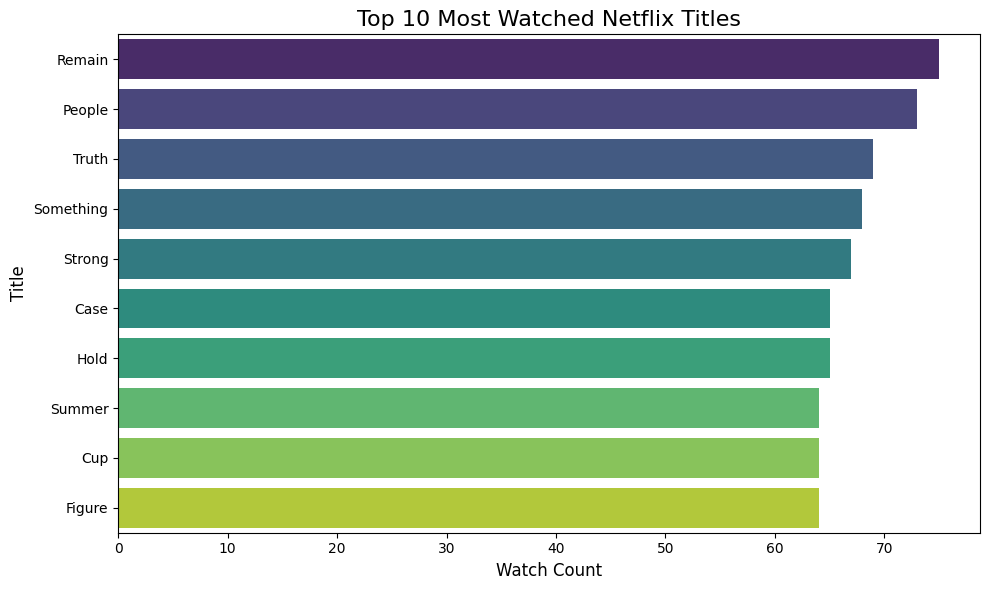

In [ ]:
# full_df is our cleaned DataFrame
import matplotlib.pyplot as plt
import seaborn as sns
# Top 10 Most Watched Titles
top_titles = full_df['title'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_titles.values, y=top_titles.index, palette="viridis")
plt.title('Top 10 Most Watched Netflix Titles', fontsize=16)
plt.xlabel('Watch Count', fontsize=12)
plt.ylabel('Title', fontsize=12)
plt.tight_layout()
plt.show()


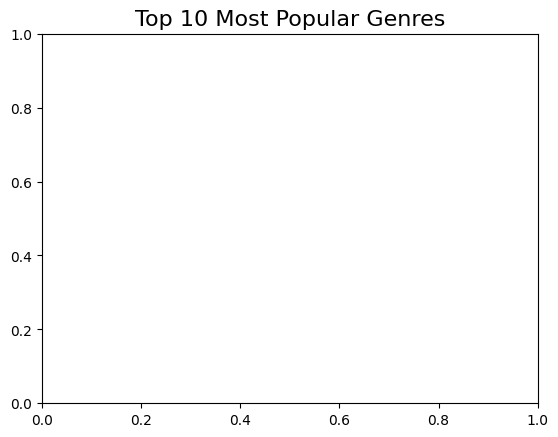

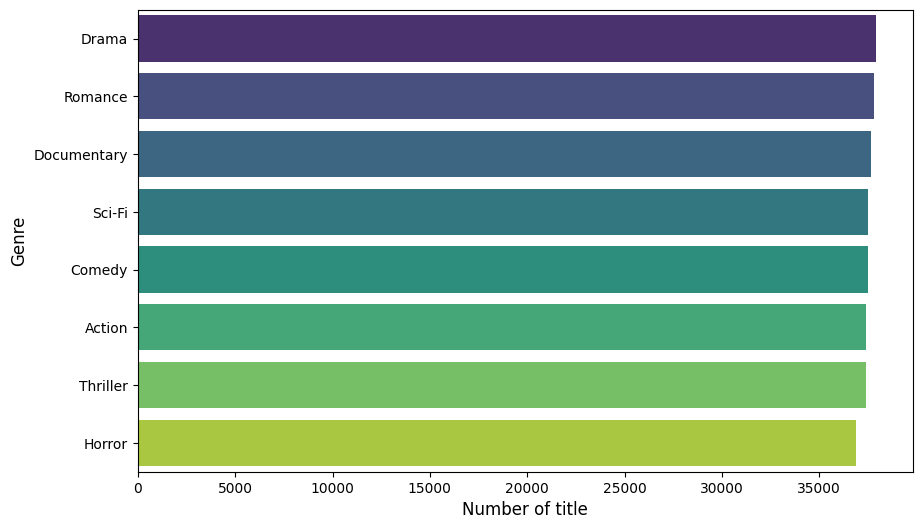

In [ ]:
# Genre Popularity
genre_count = full_df['genre'].value_counts().head(10)
plt.title("Top 10 Most Popular Genres", fontsize = 16)
plt.figure(figsize = (10,6))
sns.barplot(
    x=genre_count.values,
    y=genre_count.index,
    hue=genre_count.index,   # assign hue
    palette="viridis",
    legend=False )            # remove extra legend
plt.xlabel('Number of title', fontsize = 12)
plt.ylabel('Genre', fontsize = 12)
plt.tight_layout
plt.show()

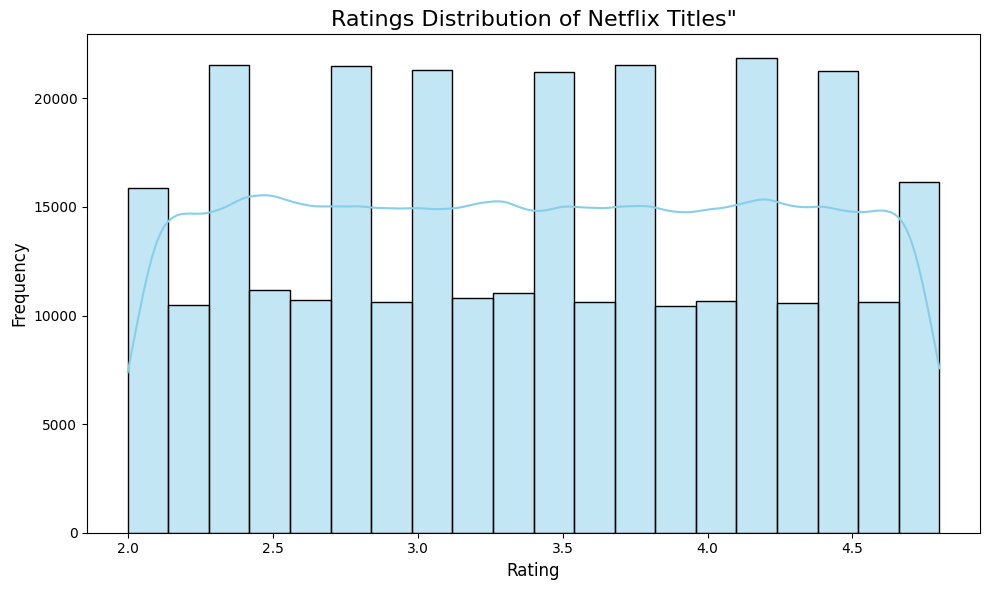

In [ ]:
# Rating distribution
plt.figure(figsize=(10,6))
sns.histplot(full_df['rating'], bins=20, kde=True, color='skyblue')
plt.title('Ratings Distribution of Netflix Titles"', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

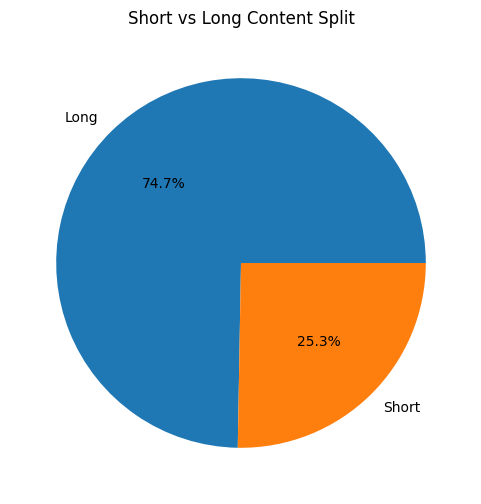

In [ ]:
# Long vs Short Content Split
full_df['content_length'] = full_df['duration_min'].apply(
    lambda x: 'Short' if x < 60 else 'Long'
)

length_count = full_df['content_length'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(length_count, labels=length_count.index, autopct='%1.1f%%')
plt.title('Short vs Long Content Split')
plt.show()

/tmp/ipykernel_13509/590265937.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_watch = full_df.groupby('age_group')['watch_time_minutes'].sum()


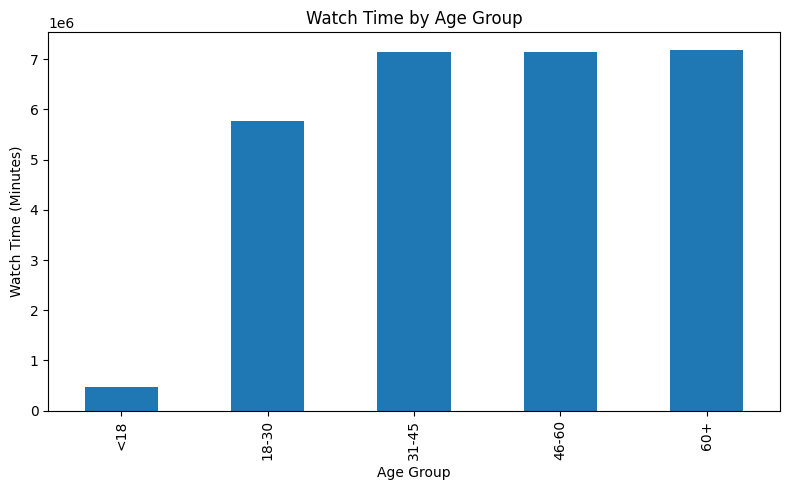

In [ ]:
# age group Engagement
age_watch = full_df.groupby('age_group')['watch_time_minutes'].sum()

plt.figure(figsize=(8,5))
age_watch.plot(kind='bar')
plt.title('Watch Time by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Watch Time (Minutes)')
plt.tight_layout()
plt.show()

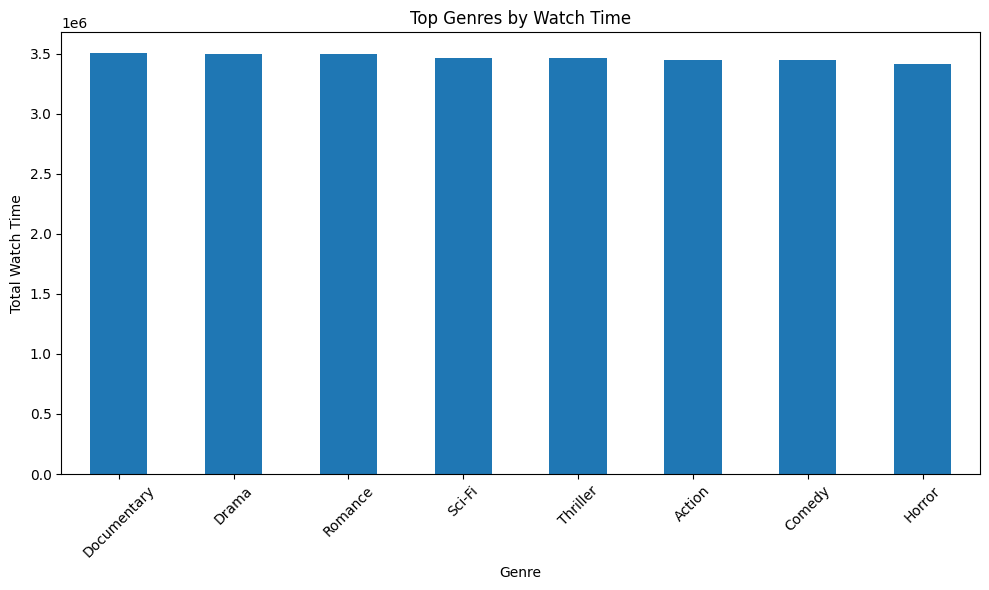

In [ ]:
# Top Genres by Watch Time
genre_watch = full_df.groupby('genre')['watch_time_minutes'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
genre_watch.plot(kind='bar')
plt.title('Top Genres by Watch Time')
plt.xlabel('Genre')
plt.ylabel('Total Watch Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_13509/327124008.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_watch = full_df.groupby('subscription_type')['watch_time_minutes'].sum()


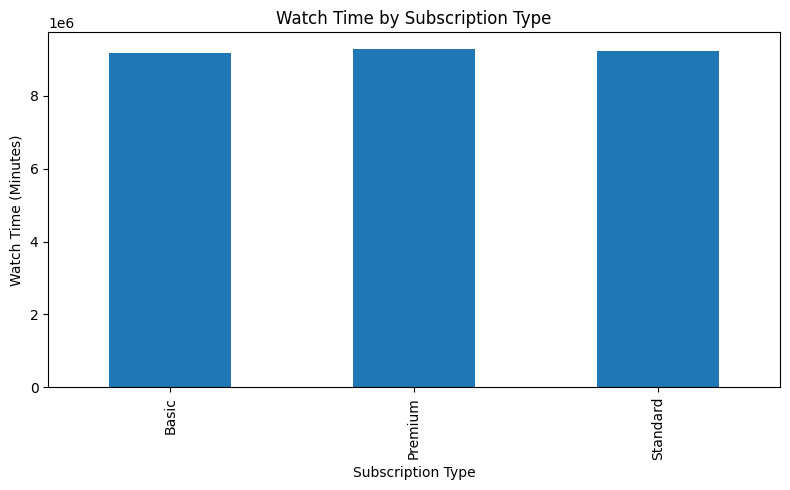

In [ ]:
# Watch Time by Subscription Type
sub_watch = full_df.groupby('subscription_type')['watch_time_minutes'].sum()

plt.figure(figsize=(8,5))
sub_watch.plot(kind='bar')
plt.title('Watch Time by Subscription Type')
plt.xlabel('Subscription Type')
plt.ylabel('Watch Time (Minutes)')
plt.tight_layout()
plt.show()

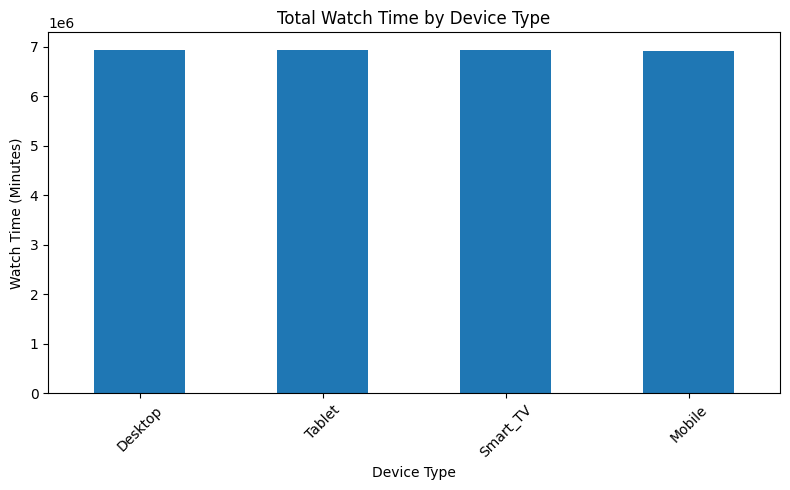

In [ ]:
# Watch Time by Device Type
device_watch = full_df.groupby('device_type')['watch_time_minutes'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
device_watch.plot(kind='bar')
plt.title('Total Watch Time by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Watch Time (Minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

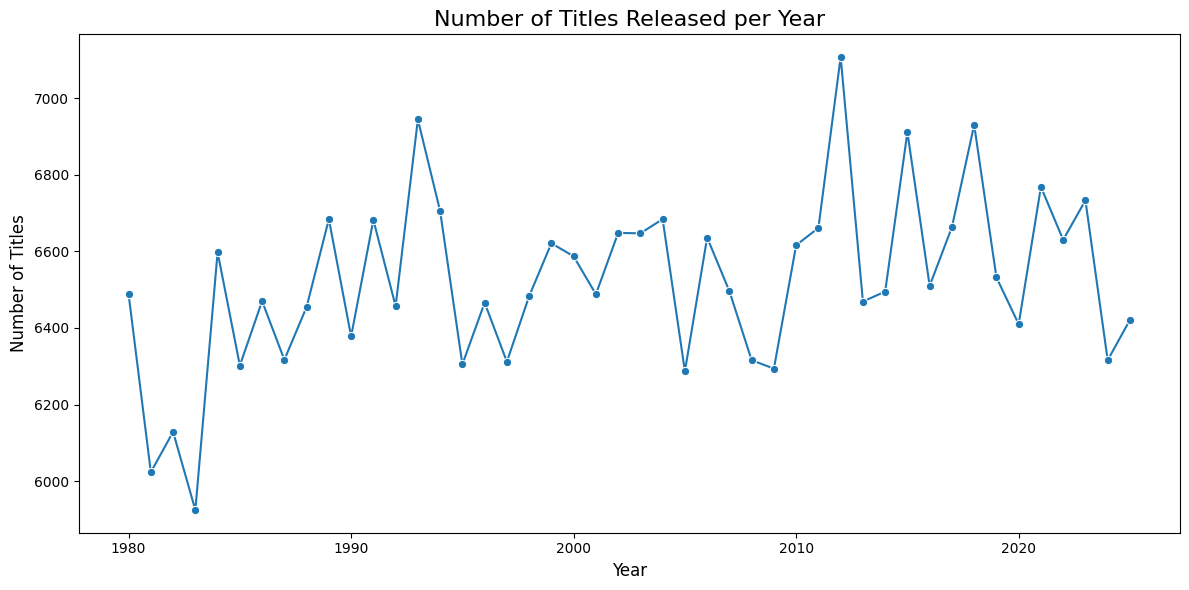

In [ ]:
# Watch Count per Year
if 'release_year' in full_df.columns:
    yearly_count = full_df['release_year'].value_counts().sort_index()
    plt.figure(figsize=(12,6))
    sns.lineplot(x=yearly_count.index, y=yearly_count.values, marker='o')
    plt.title('Number of Titles Released per Year', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Number of Titles', fontsize=12)
    plt.tight_layout()
    plt.show()

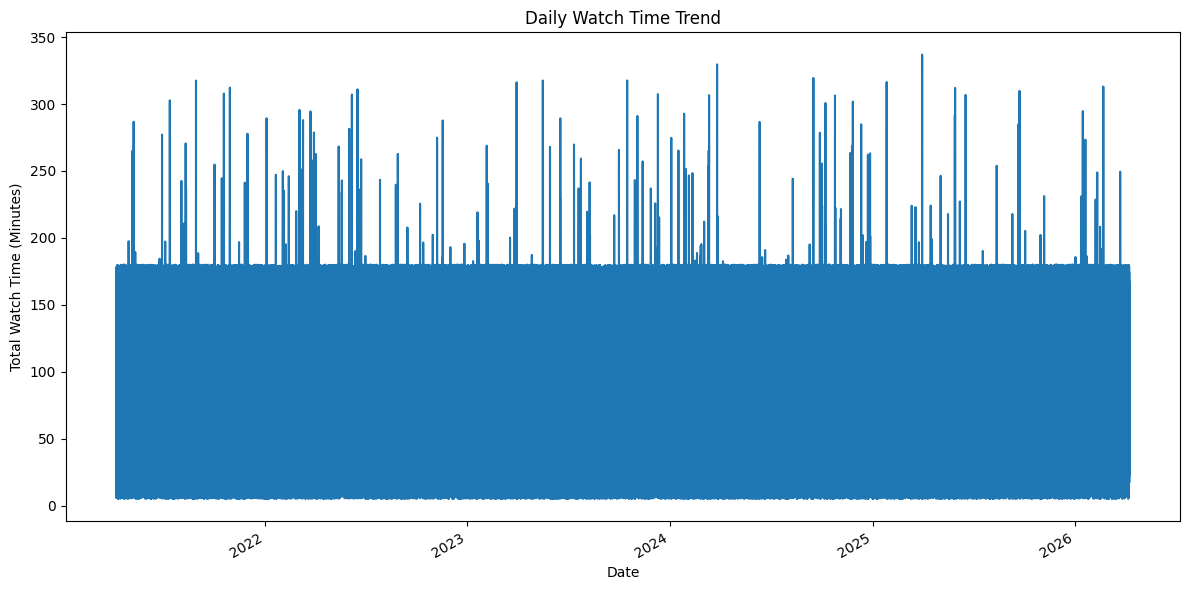

In [ ]:
# Aggregate daily watch time
daily_trend = full_df.groupby('watch_date')['watch_time_minutes'].sum()

plt.figure(figsize=(12,6))
daily_trend.plot()
plt.title('Daily Watch Time Trend')
plt.xlabel('Date')
plt.ylabel('Total Watch Time (Minutes)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_13509/772850901.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = full_df.resample('M', on='watch_date')['watch_time_minutes'].sum()


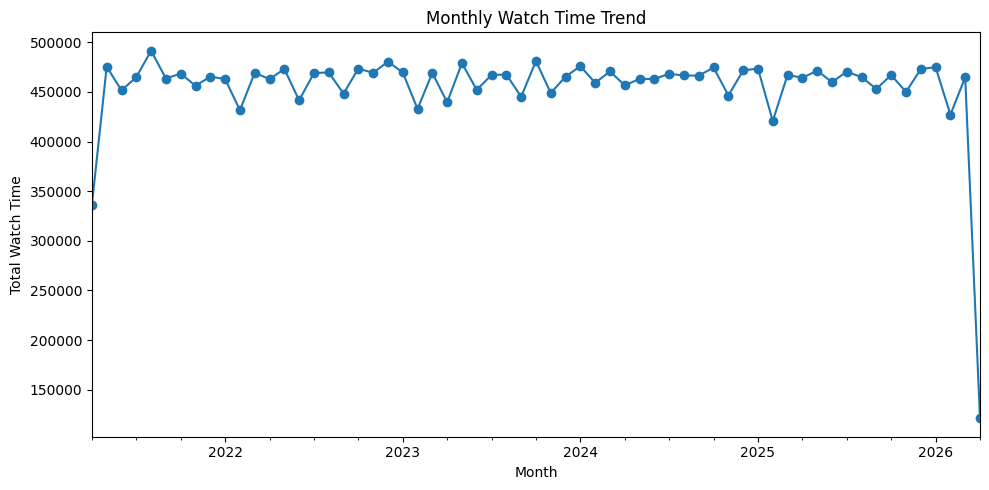

In [ ]:
# monthly trend
monthly_trend = full_df.resample('M', on='watch_date')['watch_time_minutes'].sum()

plt.figure(figsize=(10,5))
monthly_trend.plot(marker='o')
plt.title('Monthly Watch Time Trend')
plt.xlabel('Month')
plt.ylabel('Total Watch Time')
plt.tight_layout()
plt.show()